### SECTION 1 : IMPORTS — Gathering All Our Tools

# Think of this like a chef pulling out every utensil before cooking.
# We bring in all the libraries we'll need for the entire project upfront.


In [1]:
import warnings                                        # Helps us silence annoying warning messages
warnings.filterwarnings('ignore')                      # Tell Python: "Don't show me yellow warning texts"

import numpy as np                                     # The calculator of Python — handles all number crunching
import pandas as pd                                    # Like Excel for Python — loads and manages data tables

import matplotlib.pyplot as plt                        # The painter — draws all our charts and graphs
import seaborn as sns                                  # A prettier painter built on top of matplotlib

from sklearn.tree import DecisionTreeClassifier        # The star of the show — the CART model itself
from sklearn.tree import plot_tree, export_text        # Tools to visualize what our tree looks like inside

from sklearn.model_selection import (
    train_test_split,                                  # Splits data into training set and test set (like exam vs practice)
    GridSearchCV,                                      # Tries every combination of settings to find the best one
    cross_val_score,                                   # Tests the model multiple times on different portions of data
    StratifiedKFold                                    # A smart way to split data that keeps class balance intact
)

from sklearn.preprocessing import StandardScaler       # Normalizes numbers so big and small features are on equal ground

from sklearn.metrics import (
    accuracy_score,                                    # "How often was the model right?" — simplest metric
    confusion_matrix,                                  # A table showing where the model got confused
    classification_report,                             # A detailed report card for the model
    roc_auc_score,                                     # Measures how well model separates Hired vs Not Hired
    roc_curve,                                         # Data points to draw the ROC curve graph
    precision_recall_curve,                            # Data points to draw the Precision-Recall graph
    average_precision_score                            # Summary score of the Precision-Recall curve
)

print("✅ All libraries loaded successfully! We're ready to build the model.")
print("=" * 70)

✅ All libraries loaded successfully! We're ready to build the model.


### SECTION 2 : PROBLEM STATEMENT — What Are We Solving?
# Before building anything, a good data scientist always asks:
# "What business problem am I solving?"

In [2]:
print("""
BUSINESS PROBLEM:
-----------------
Imagine you are an HR Manager at a company. Every week, you receive
hundreds of resumes. You have to screen each candidate manually —
reading their qualifications, checking scores, and deciding:
"Should we hire this person or not?"

This is SLOW, EXPENSIVE, and sometimes BIASED.

OUR GOAL:
---------
Build a machine learning model (CART — Classification and Regression Tree)
that learns from PAST hiring decisions and can PREDICT whether a new
candidate will be hired — automatically and consistently.

Think of it like this: We're training a junior recruiter by showing them
1,500 past decisions. They learn the pattern. Then they apply that pattern
to new candidates.

DATASET:
--------
- 1,500 candidates (rows)
- 10 features (columns) about each candidate
- 1 target column: HiringDecision (0 = Not Hired, 1 = Hired)
""")
print("=" * 70)



BUSINESS PROBLEM:
-----------------
Imagine you are an HR Manager at a company. Every week, you receive
hundreds of resumes. You have to screen each candidate manually —
reading their qualifications, checking scores, and deciding:
"Should we hire this person or not?"
 
This is SLOW, EXPENSIVE, and sometimes BIASED.
 
OUR GOAL:
---------
Build a machine learning model (CART — Classification and Regression Tree)
that learns from PAST hiring decisions and can PREDICT whether a new
candidate will be hired — automatically and consistently.
 
Think of it like this: We're training a junior recruiter by showing them
1,500 past decisions. They learn the pattern. Then they apply that pattern
to new candidates.
 
DATASET:
--------
- 1,500 candidates (rows)
- 10 features (columns) about each candidate
- 1 target column: HiringDecision (0 = Not Hired, 1 = Hired)



### SECTION 3 : LOAD DATA — Open the Excel Sheet
## A DataFrame is basically a smart table in Python.

In [3]:
df = pd.read_csv('recruitment_data.csv')              # Load the CSV file into a table called 'df'

print("\nSECTION 3 : LOAD DATA")
print("=" * 70)

# Show the first 5 rows — like glancing at the top of a spreadsheet
print("\n📋 First 5 Rows of Data:")
print(df.head())

# Show shape — how many rows and columns do we have?
print(f"\n📐 Dataset Shape : {df.shape[0]} rows × {df.shape[1]} columns")

# Show data types — what kind of values are in each column?
print("\n🔎 Column Data Types:")
print(df.dtypes)

# Check for missing values — are there any empty cells?
print("\n❓ Missing Values Per Column:")
print(df.isnull().sum())
print("→ No missing values! Dataset is clean. No imputation needed.")

# Show what values the target column contains
print("\n🎯 Target Column (HiringDecision) Distribution:")
vc = df['HiringDecision'].value_counts()               # Count how many 0s and 1s there are
print(f"  Not Hired (0): {vc[0]} candidates ({vc[0]/len(df):.1%})")
print(f"  Hired     (1): {vc[1]} candidates ({vc[1]/len(df):.1%})")
print("→ Dataset is imbalanced: more candidates were NOT hired.")
print("  This means Accuracy alone is not a good metric — we'll use ROC-AUC too.")

print("=" * 70)



SECTION 3 : LOAD DATA

📋 First 5 Rows of Data:
   Age  Gender  EducationLevel  ExperienceYears  PreviousCompanies  \
0   26       1               2                0                  3   
1   39       1               4               12                  3   
2   48       0               2                3                  2   
3   34       1               2                5                  2   
4   30       0               1                6                  1   

   DistanceFromCompany  InterviewScore  SkillScore  PersonalityScore  \
0            26.783828              48          78                91   
1            25.862694              35          68                80   
2             9.920805              20          67                13   
3             6.407751              36          27                70   
4            43.105343              23          52                85   

   RecruitmentStrategy  HiringDecision  
0                    1               1  
1               

### SECTION 4 : EXPLORATORY DATA ANALYSIS (EDA) — Getting to Know the Data

# EDA is like reading a book's summary before diving into details.
# We explore patterns, distributions, and relationships in the data.


SECTION 4 : EXPLORATORY DATA ANALYSIS (EDA)

📊 Statistical Summary (Describe):
           Age   Gender  EducationLevel  ExperienceYears  PreviousCompanies  \
count  1500.00  1500.00         1500.00          1500.00            1500.00   
mean     35.15     0.49            2.19             7.69               3.00   
std       9.25     0.50            0.86             4.64               1.41   
min      20.00     0.00            1.00             0.00               1.00   
25%      27.00     0.00            2.00             4.00               2.00   
50%      35.00     0.00            2.00             8.00               3.00   
75%      43.00     1.00            3.00            12.00               4.00   
max      50.00     1.00            4.00            15.00               5.00   

       DistanceFromCompany  InterviewScore  SkillScore  PersonalityScore  \
count              1500.00         1500.00     1500.00           1500.00   
mean                 25.51           50.56       51.12  

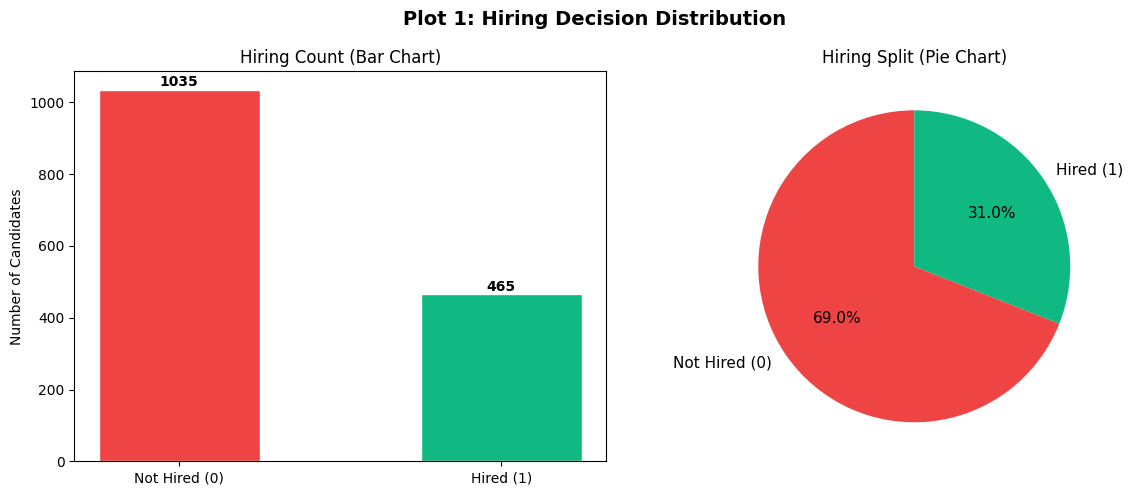

In [4]:
print("\nSECTION 4 : EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 70)

# Show statistical summary — min, max, mean, std for each column
print("\n📊 Statistical Summary (Describe):")
print(df.describe().round(2))                          # .round(2) keeps only 2 decimal places for readability


# ── PLOT 1: Target Distribution (Pie + Bar) ──────────────────────────────────
# We want to see visually how many candidates were hired vs not hired

fig, axes = plt.subplots(1, 2, figsize=(12, 5))        # Create 1 row, 2 column plot area
fig.suptitle('Plot 1: Hiring Decision Distribution', fontsize=14, fontweight='bold')

# Bar chart — left side
counts = df['HiringDecision'].value_counts()           # Count values
labels = ['Not Hired (0)', 'Hired (1)']                # Human-readable labels
colors_bar = ['#EF4444', '#10B981']                    # Red for Not Hired, Green for Hired
axes[0].bar(labels, counts.values, color=colors_bar, edgecolor='white', width=0.5)  # Draw the bars
axes[0].set_title('Hiring Count (Bar Chart)')          # Title for this subplot
axes[0].set_ylabel('Number of Candidates')             # Y-axis label
for i, v in enumerate(counts.values):                 # Loop to add number labels on top of bars
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')  # Place text above each bar

# Pie chart — right side
axes[1].pie(counts.values, labels=labels, colors=colors_bar,          # Draw pie slices
            autopct='%1.1f%%', startangle=90, textprops={'fontsize': 11})  # Show % inside each slice
axes[1].set_title('Hiring Split (Pie Chart)')          # Title for pie chart

plt.tight_layout()                                     # Auto-adjust spacing so nothing overlaps
plt.show()                                             # 📺 SHOW THE CHART INLINE (not saved to file!)


## PLOT 2: Feature Distributions
# Think of this as looking at the "profile" of all candidates — their age, scores, etc.

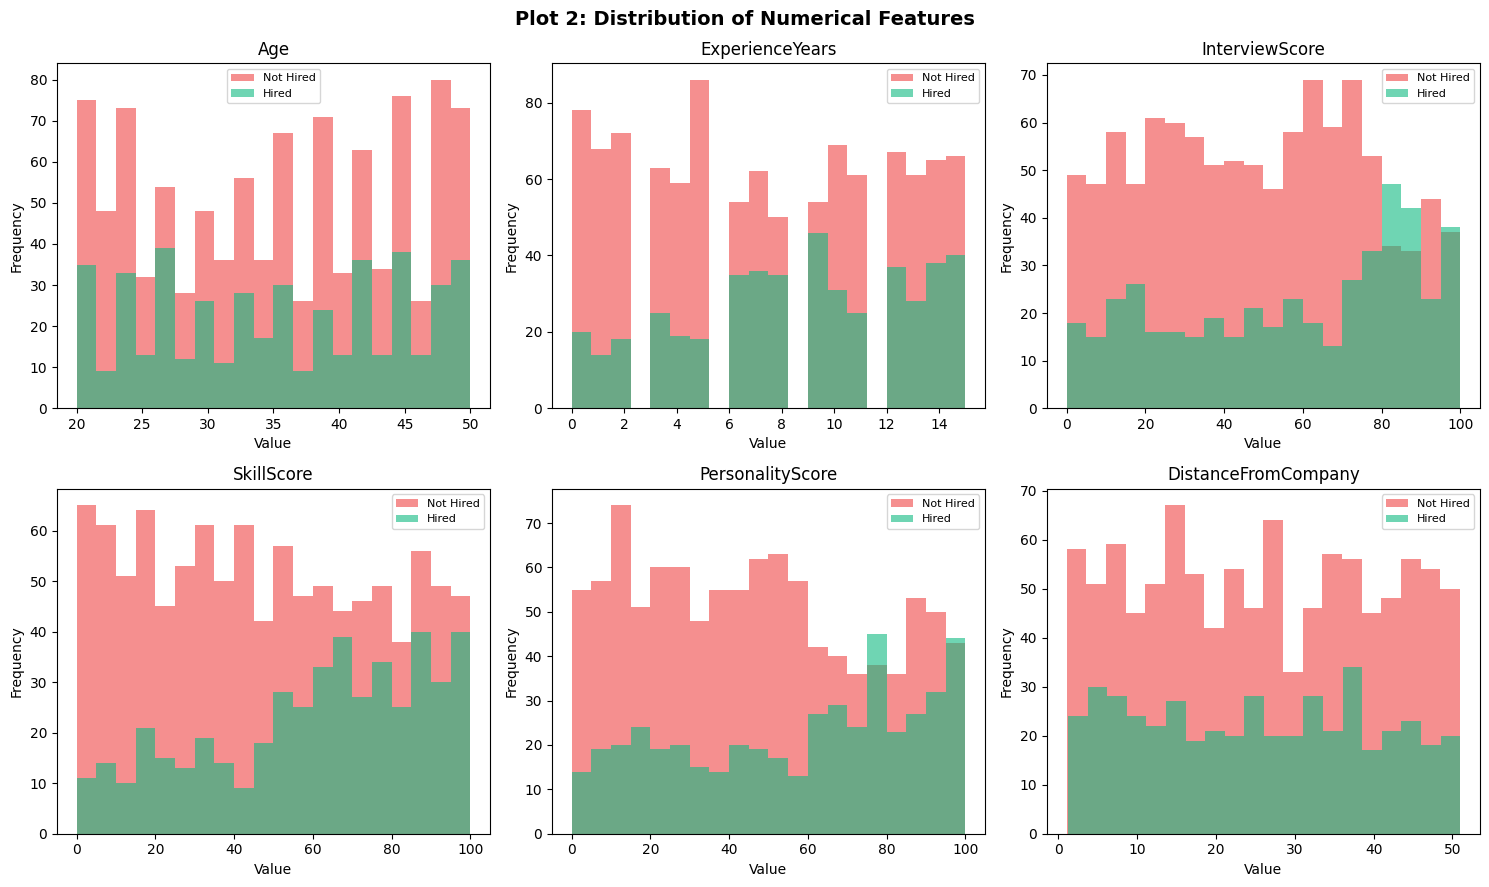

In [5]:
num_cols = ['Age', 'ExperienceYears', 'InterviewScore',
            'SkillScore', 'PersonalityScore', 'DistanceFromCompany']  # Numerical columns to visualize

fig, axes = plt.subplots(2, 3, figsize=(15, 9))        # 2 rows × 3 columns of plots
fig.suptitle('Plot 2: Distribution of Numerical Features', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):                     # Loop through each numerical column
    ax = axes[i // 3][i % 3]                          # Calculate which subplot position to use
    # Overlay two histograms: one for Hired (green), one for Not Hired (red)
    df[df['HiringDecision'] == 0][col].plot(kind='hist', bins=20, alpha=0.6,
                                             color='#EF4444', ax=ax, label='Not Hired')
    df[df['HiringDecision'] == 1][col].plot(kind='hist', bins=20, alpha=0.6,
                                             color='#10B981', ax=ax, label='Hired')
    ax.set_title(col)                                  # Use column name as subplot title
    ax.set_xlabel('Value')                             # X-axis label
    ax.legend(fontsize=8)                              # Show legend (Hired / Not Hired)

plt.tight_layout()
plt.show()

## ── PLOT 3: Correlation Heatmap
# A heatmap shows how strongly each feature is related to every other feature.
# Like asking: "If someone scores high on Skill, do they also tend to score high on Interview?"

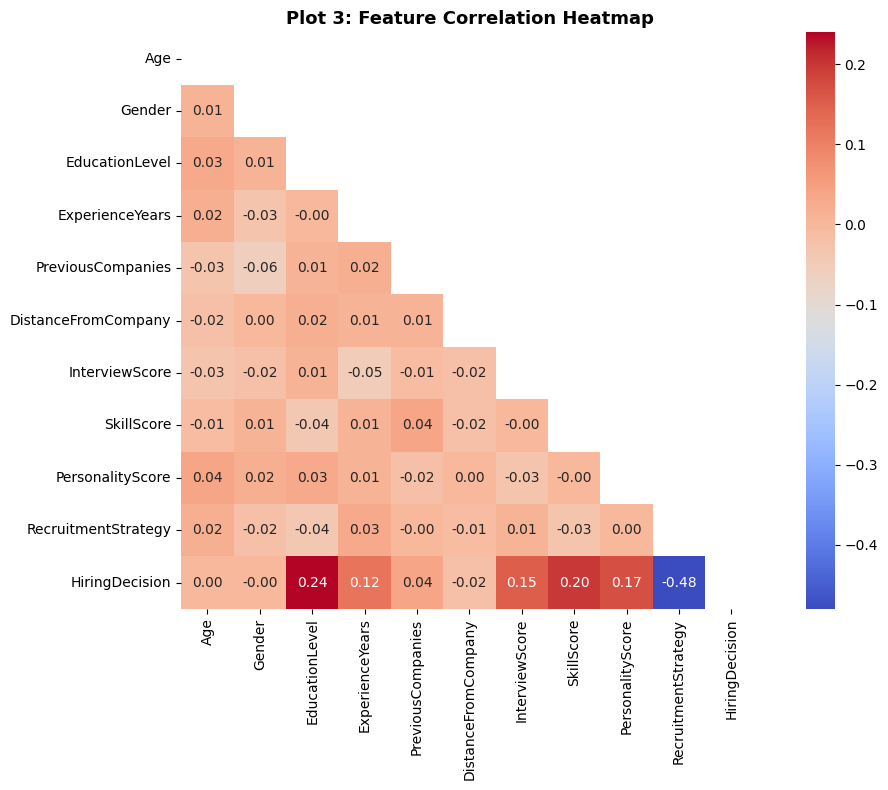

→ InterviewScore and SkillScore are relatively independent of each other.
  Both seem to have positive relationships with HiringDecision.


In [6]:
fig, ax = plt.subplots(figsize=(11, 8))                # Single large plot
mask = np.triu(np.ones_like(df.corr(), dtype=bool))   # Mask upper triangle (it's a mirror of lower)
sns.heatmap(df.corr().round(2),                        # Correlation matrix, rounded to 2 decimals
            annot=True,                                # Show the numbers inside each cell
            fmt='.2f',                                 # Format: 2 decimal places
            cmap='coolwarm',                           # Color: blue (negative) → red (positive)
            mask=mask,                                 # Hide the upper half (redundant)
            ax=ax,
            square=True)
ax.set_title('Plot 3: Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()                                             # 📺 Show inline!

print("→ InterviewScore and SkillScore are relatively independent of each other.")
print("  Both seem to have positive relationships with HiringDecision.")
print("=" * 70)


#PLOT 4: Boxplots by Hiring Decision
# Boxplots show the spread and median of each feature, separated by hired vs not hired.
# Great for spotting which features clearly differ between the two groups.


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Plot 4: Feature Boxplots by Hiring Decision', fontsize=14, fontweight='bold')

for i, col in enumerate(num_cols):
    ax = axes[i // 3][i % 3]
    # Draw boxplot: x = target (0 or 1), y = the feature value
    sns.boxplot(data=df, x='HiringDecision', y=col,
                palette=['#EF4444', '#10B981'], ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Hiring Decision (0=No, 1=Yes)')

plt.tight_layout()
plt.show()                                             # 📺 Show inline!

print("→ Hired candidates tend to have higher InterviewScore and SkillScore.")
print("  This gives us confidence these features will help the model.")
print("=" * 70)

##SECTION 5 : PREPROCESSING — Preparing the Data for the Model
# Before feeding data to the model, we need to:
# 1. Separate features (inputs) from the target (output)
# 2. Scale the numbers so all features are on the same level
# 3. Split data into training set (for learning) and test set (for evaluation)

In [8]:
print("\nSECTION 5 : PREPROCESSING")
print("=" * 70)

# Step 1: Separate X (features) and y (target)
# Imagine X = everything you know about a candidate (age, score, etc.)
#         y = the actual decision (hired or not)
X = df.drop('HiringDecision', axis=1)                 # X = all columns EXCEPT the target
y = df['HiringDecision']                               # y = only the target column
print(f"\n  Features (X): {X.shape}  →  {list(X.columns)}")
print(f"  Target   (y): {y.shape}  →  {y.unique()}")

# Step 2: Scale the features using StandardScaler
# Think of it like converting everyone's salary to a common currency.
# A "distance from company" of 40km shouldn't overpower an "interview score" of 75
# just because 40 looks bigger than 75 in the wrong unit context.
# Note: CART doesn't technically NEED scaling (it uses thresholds, not distances).
# But we include it for pipeline best practice and compatibility with other models.
scaler = StandardScaler()                              # Create the scaler object
X_scaled = scaler.fit_transform(X)                    # Learn the scale from data, then apply it
X_scaled = pd.DataFrame(X_scaled, columns=X.columns) # Convert back to DataFrame (keeps column names)
print("\n  StandardScaler applied. All features now have mean=0 and std=1.")




SECTION 5 : PREPROCESSING

  Features (X): (1500, 10)  →  ['Age', 'Gender', 'EducationLevel', 'ExperienceYears', 'PreviousCompanies', 'DistanceFromCompany', 'InterviewScore', 'SkillScore', 'PersonalityScore', 'RecruitmentStrategy']
  Target   (y): (1500,)  →  [1 0]

  StandardScaler applied. All features now have mean=0 and std=1.


## Step 3: Train-Test Split
# We keep 80% of data for training (learning) and 20% for testing (evaluation).
# stratify=y ensures both splits have the same ratio of Hired vs Not Hired.
# Think of it like dividing your study material: 80% for practice, 20% for mock exam.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.20,                                   # 20% goes to test set
    random_state=42,                                  # Seed for reproducibility (same split every run)
    stratify=y                                        # Maintain class proportion in both splits
)

print(f"\n  Training Set : {X_train.shape[0]} samples")
print(f"  Test Set     : {X_test.shape[0]} samples")
print(f"  Train Hire % : {y_train.mean():.2%}")
print(f"  Test  Hire % : {y_test.mean():.2%}")
print("  → Both splits have similar hire rates. Stratification worked!")



  Training Set : 1200 samples
  Test Set     : 300 samples
  Train Hire % : 31.00%
  Test  Hire % : 31.00%
  → Both splits have similar hire rates. Stratification worked!


## SECTION 6 : BASELINE CART MODEL — First Draft, No Tuning
# This is like writing a rough first draft of an essay.
# We build the simplest possible model to establish a starting benchmark.
# If our advanced model isn't better than this, something's wrong!

# Create the model — no restrictions on tree depth (it'll grow as big as it wants!)
# criterion='gini' means the model uses Gini Impurity to decide where to split.
# Gini measures "how mixed" a group is — pure groups (all hired or all not) = better.

In [11]:
cart_base = DecisionTreeClassifier(
    criterion='gini',                                 # Splitting rule (Gini Impurity)
    random_state=42                                   # For reproducible results
)

## Train the model — this is where the "learning" happens
# The model looks at X_train and y_train and figures out splitting rules

In [12]:
cart_base.fit(X_train, y_train)                       # "Teach" the model on training data

DecisionTreeClassifier(random_state=42)

# Make predictions on the TEST set (data the model has never seen!)

In [13]:
y_pred_base = cart_base.predict(X_test)               # Binary predictions: 0 or 1
y_prob_base = cart_base.predict_proba(X_test)[:, 1]  # Probabilities for class=1 (Hired)

In [14]:
# Print results
print(f"\n  Baseline Accuracy : {accuracy_score(y_test, y_pred_base):.4f}")
print(f"  Baseline ROC-AUC  : {roc_auc_score(y_test, y_prob_base):.4f}")
print(f"  Tree Depth        : {cart_base.get_depth()} levels deep!")
print(f"  Number of Leaves  : {cart_base.get_n_leaves()} decision leaves")
print("  → VERY deep tree = likely overfitting (memorizing training data, not generalizing)")
print("=" * 70)


  Baseline Accuracy : 0.8933
  Baseline ROC-AUC  : 0.8724
  Tree Depth        : 13 levels deep!
  Number of Leaves  : 109 decision leaves
  → VERY deep tree = likely overfitting (memorizing training data, not generalizing)


## SECTION 7 : MODEL EVALUATION — Baseline — How Good Is Our First Draft?
# Now we evaluate the model using multiple metrics.
# Accuracy: "What % of candidates did we predict correctly?"
# Confusion Matrix: "Where exactly did we go wrong?"
# ROC-AUC: "How well does the model RANK candidates by likelihood of being hired?"

In [15]:
print("\n📋 Classification Report (Baseline):")
# This report gives Precision, Recall, F1-Score for each class
# Precision = "Of all people we predicted as Hired, how many actually were?"
# Recall    = "Of all people who were actually Hired, how many did we catch?"
print(classification_report(y_test, y_pred_base, target_names=['Not Hired', 'Hired']))


📋 Classification Report (Baseline):
              precision    recall  f1-score   support

   Not Hired       0.92      0.93      0.92       207
       Hired       0.84      0.82      0.83        93

    accuracy                           0.89       300
   macro avg       0.88      0.87      0.87       300
weighted avg       0.89      0.89      0.89       300



#PLOT 5: Confusion Matrix
# Think of this as a "where did we make mistakes?" table.
# Rows = actual (real answer), Columns = predicted (model's answer)
# Correct predictions are on the diagonal, mistakes are off-diagonal.

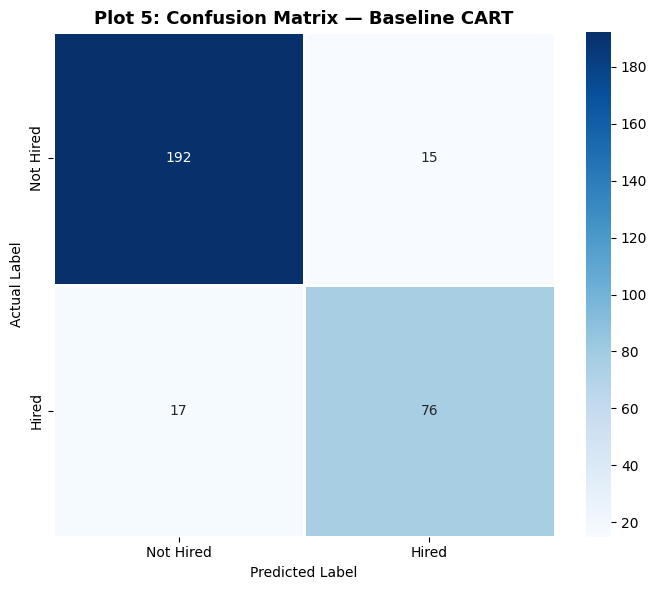

  True Negatives  (correctly said Not Hired): 192
  False Positives (wrongly said Hired)      : 15
  False Negatives (wrongly said Not Hired)  : 17
  True Positives  (correctly said Hired)    : 76


In [17]:
cm_base = confusion_matrix(y_test, y_pred_base)       # Build the confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_base, annot=True, fmt='d', cmap='Blues', ax=ax,  # Draw as colored table
            xticklabels=['Not Hired', 'Hired'],
            yticklabels=['Not Hired', 'Hired'],
            linewidths=1, linecolor='white')
ax.set_title('Plot 5: Confusion Matrix — Baseline CART', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual Label')                         # What really happened
ax.set_xlabel('Predicted Label')                      # What our model predicted
plt.tight_layout()
plt.show()                                             # 📺 Show inline!

print(f"  True Negatives  (correctly said Not Hired): {cm_base[0][0]}")
print(f"  False Positives (wrongly said Hired)      : {cm_base[0][1]}")
print(f"  False Negatives (wrongly said Not Hired)  : {cm_base[1][0]}")
print(f"  True Positives  (correctly said Hired)    : {cm_base[1][1]}")

#PLOT 6: ROC Curve — Baseline
# The ROC Curve shows how well the model can separate the two classes.
# AUC (Area Under Curve) closer to 1.0 = excellent model
# AUC = 0.5 = random guessing (useless model, like flipping a coin)

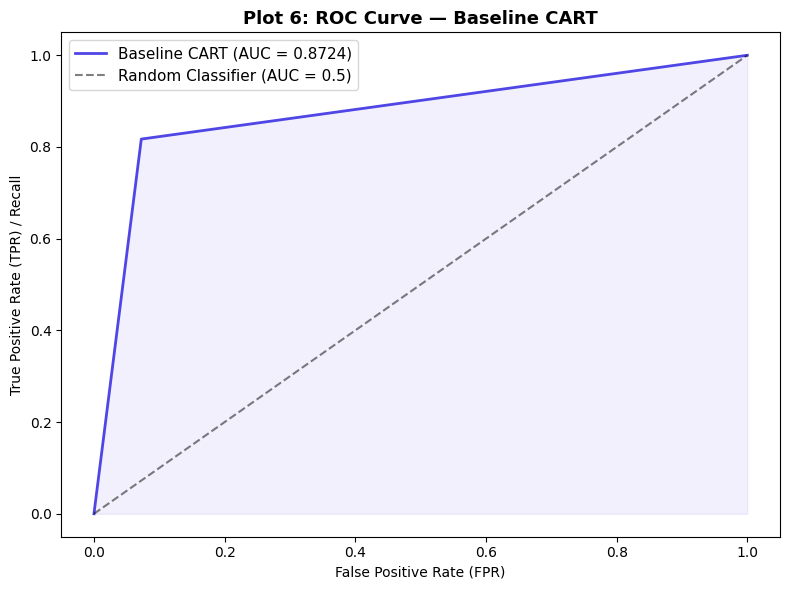

In [18]:
fpr, tpr, _ = roc_curve(y_test, y_prob_base)          # False Positive Rate, True Positive Rate
auc_base = roc_auc_score(y_test, y_prob_base)          # Single number summary

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#4F46E5', lw=2,              # Draw the ROC curve
        label=f'Baseline CART (AUC = {auc_base:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.5,    # Diagonal = random baseline
        label='Random Classifier (AUC = 0.5)')
ax.fill_between(fpr, tpr, alpha=0.08, color='#4F46E5') # Shade area under the curve
ax.set_title('Plot 6: ROC Curve — Baseline CART', fontsize=13, fontweight='bold')
ax.set_xlabel('False Positive Rate (FPR)')             # X-axis
ax.set_ylabel('True Positive Rate (TPR) / Recall')    # Y-axis
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()                                             # 📺 Show inline!

print("=" * 70)

## SECTION 8 : TREE VISUALIZATION — What Does the Tree Look Like?
# The coolest thing about CART is that you can actually SEE the decisions it makes!
# Each branch is a "Yes/No" question, just like a flowchart.
# We show depth=3 for readability (the full tree is too big to display clearly).

In [19]:
print("\nSECTION 8 : TREE VISUALIZATION")
print("=" * 70)

print("\n📜 Text Representation of Tree (first 3 levels):")
# Export the decision rules as readable text
tree_text = export_text(cart_base, feature_names=list(X.columns), max_depth=3)
print(tree_text)
print("(Showing only first 3 levels for readability. Full tree goes much deeper.)")


SECTION 8 : TREE VISUALIZATION

📜 Text Representation of Tree (first 3 levels):
|--- RecruitmentStrategy <= -0.57
|   |--- SkillScore <= -0.06
|   |   |--- PersonalityScore <= 0.41
|   |   |   |--- EducationLevel <= 0.36
|   |   |   |   |--- truncated branch of depth 5
|   |   |   |--- EducationLevel >  0.36
|   |   |   |   |--- truncated branch of depth 4
|   |   |--- PersonalityScore >  0.41
|   |   |   |--- ExperienceYears <= -0.47
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- ExperienceYears >  -0.47
|   |   |   |   |--- truncated branch of depth 5
|   |--- SkillScore >  -0.06
|   |   |--- ExperienceYears <= -0.47
|   |   |   |--- PersonalityScore <= 0.16
|   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- PersonalityScore >  0.16
|   |   |   |   |--- truncated branch of depth 6
|   |   |--- ExperienceYears >  -0.47
|   |   |   |--- InterviewScore <= -1.68
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- InterviewScore >  -1.68
| 

#PLOT 7: Visual Tree Diagram
# This creates a visual flowchart of how the tree makes decisions.
# Think of it as an org chart for decision-making!

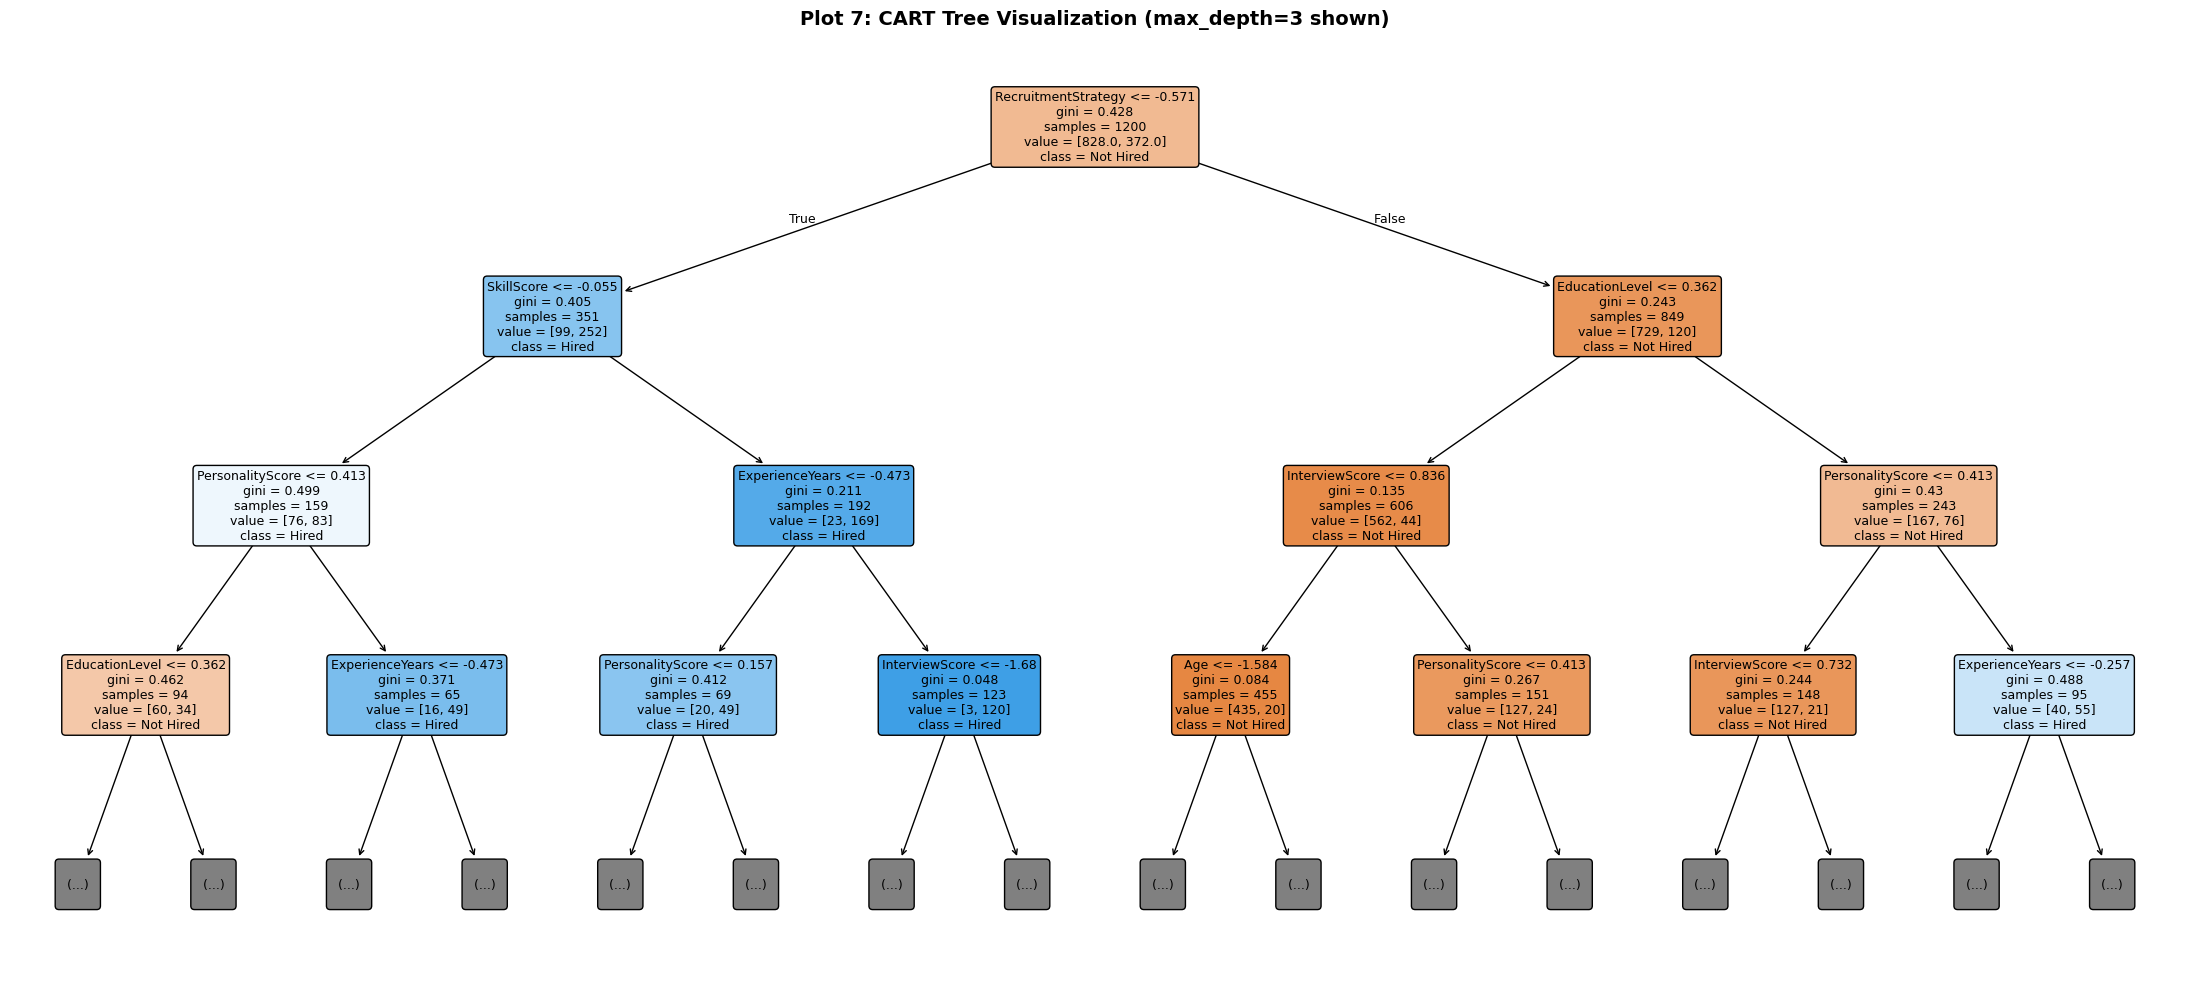

→ Each box = one decision node. Blue = mostly Not Hired, Orange = mostly Hired.


In [20]:
fig, ax = plt.subplots(figsize=(22, 10))               # Large figure for the tree diagram
plot_tree(
    cart_base,
    max_depth=3,                                       # Show only top 3 levels
    feature_names=list(X.columns),                    # Use actual column names
    class_names=['Not Hired', 'Hired'],                # Labels for leaf nodes
    filled=True,                                       # Color the boxes by majority class
    rounded=True,                                      # Rounded corners look nice
    fontsize=9,
    ax=ax
)
ax.set_title('Plot 7: CART Tree Visualization (max_depth=3 shown)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()                                             # 📺 Show inline!

print("→ Each box = one decision node. Blue = mostly Not Hired, Orange = mostly Hired.")
print("=" * 70)

## SECTION 9 : FEATURE IMPORTANCE — Which Features Actually Matter?
# Feature importance tells us: "Which input variables did the model rely on most?"
# Like asking: "What was the biggest factor in the hiring decision?"
# Higher importance = model used this feature for more important splits.

In [21]:
# Get feature importance scores from the trained model
feat_imp = pd.Series(
    cart_base.feature_importances_,                   # Array of importance values
    index=X.columns                                   # Match to column names
).sort_values(ascending=False)                        # Sort from most to least important

print("\n  Feature Importance Scores (Baseline CART):")
for feat, score in feat_imp.items():
    bar = "█" * int(score * 50)                       # Simple ASCII bar chart
    print(f"  {feat:<25} {score:.4f}  {bar}")


  Feature Importance Scores (Baseline CART):
  RecruitmentStrategy       0.3271  ████████████████
  ExperienceYears           0.1429  ███████
  SkillScore                0.1408  ███████
  InterviewScore            0.1323  ██████
  PersonalityScore          0.1033  █████
  EducationLevel            0.0829  ████
  Age                       0.0329  █
  DistanceFromCompany       0.0239  █
  PreviousCompanies         0.0083  
  Gender                    0.0057  


#PLOT 8: Feature Importance Bar Chart

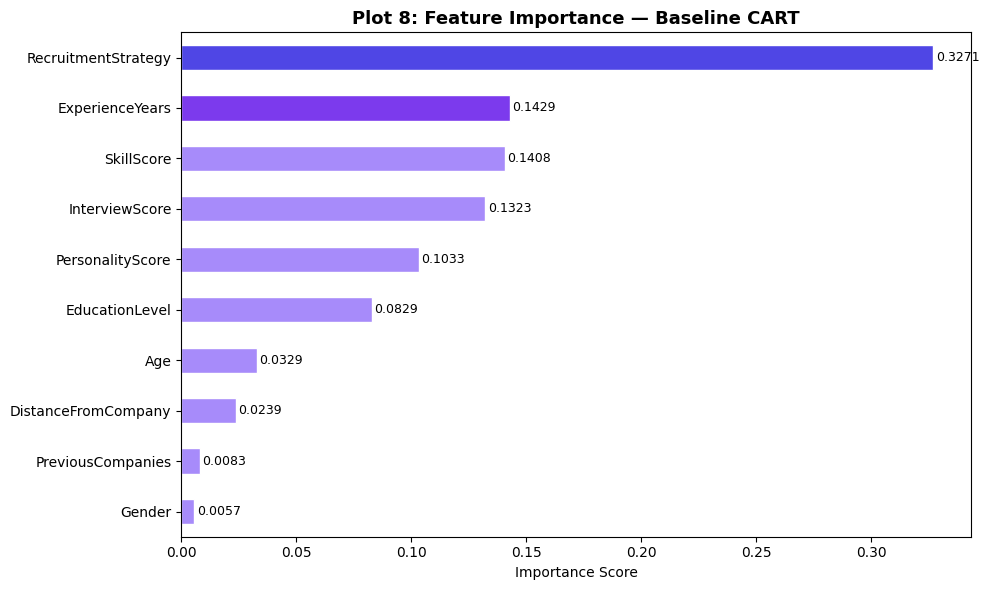

In [22]:
fig, ax = plt.subplots(figsize=(10, 6))
colors_feat = ['#4F46E5' if i == 0 else '#7C3AED' if i == 1
               else '#A78BFA' for i in range(len(feat_imp))]  # Top feature gets darkest color
feat_imp.plot(kind='barh', ax=ax, color=colors_feat,          # Horizontal bar chart
              edgecolor='white')
ax.invert_yaxis()                                      # Most important at the top
ax.set_title('Plot 8: Feature Importance — Baseline CART', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
for i, v in enumerate(feat_imp.values):               # Add value labels on each bar
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

#SECTION 10 : HYPERPARAMETER TUNING — GridSearchCV
# So far, our baseline model used DEFAULT settings.
# Hyperparameters are the "knobs and dials" we can adjust to make the model better.
#
# Think of it like baking a cake: you adjust temperature, baking time, sugar ratio
# until you get the perfect cake. GridSearchCV tries every possible combination!
#
# Key parameters we're tuning:
# - max_depth: How many levels deep the tree goes (deeper = more complex)
# - min_samples_split: Minimum samples needed before making a new split
# - min_samples_leaf: Minimum samples required to be at a leaf (end node)
# - criterion: The mathematical formula used to measure split quality (gini vs entropy)


In [23]:
# Define the parameter grid — all combinations will be tested
param_grid = {
    'max_depth'        : [3, 5, 7, 10, None],         # None = unlimited depth
    'min_samples_split': [2, 5, 10],                  # Min samples to allow a split
    'min_samples_leaf' : [1, 2, 4],                   # Min samples required at each leaf
    'criterion'        : ['gini', 'entropy'],          # Split quality measure
}
# Total combinations = 5 × 3 × 3 × 2 = 90 combinations × 5 folds = 450 model fits!
print(f"\n  Total parameter combinations: 5×3×3×2 = 90")
print(f"  With 5-fold CV, total model fits: 90 × 5 = 450")


  Total parameter combinations: 5×3×3×2 = 90
  With 5-fold CV, total model fits: 90 × 5 = 450


In [24]:
# StratifiedKFold: Split data into 5 folds, keeping class balance in each fold.
# Think of it as dividing a shuffled deck into 5 equal piles,
# making sure each pile has a similar ratio of hired vs not hired cards.

In [25]:
cv_strategy = StratifiedKFold(
    n_splits=5,                                       # 5 equal folds
    shuffle=True,                                     # Shuffle data before splitting
    random_state=42                                   # For reproducibility
)

In [26]:
# GridSearchCV: The automated trial-and-error machine.
# It trains a model for EVERY combination and picks the winner.

In [27]:
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42), # The base model to tune
    param_grid=param_grid,                             # All combinations to try
    cv=cv_strategy,                                    # Cross-validation strategy
    scoring='roc_auc',                                 # Score each combo using ROC-AUC
    n_jobs=-1,                                         # Use all CPU cores for speed
    verbose=0                                          # Don't print progress (keeps output clean)
)

print("\n  ⏳ Running GridSearchCV... (trying all 90 combinations)")
grid_search.fit(X_train, y_train)                     # Run the search — this trains 450 models!

print(f"\n  ✅ Best Parameters Found:")
for k, v in grid_search.best_params_.items():
    print(f"     {k:<22} = {v}")
print(f"\n  Best CV ROC-AUC : {grid_search.best_score_:.4f}")


  ⏳ Running GridSearchCV... (trying all 90 combinations)

  ✅ Best Parameters Found:
     criterion              = gini
     max_depth              = None
     min_samples_leaf       = 4
     min_samples_split      = 2

  Best CV ROC-AUC : 0.9093


In [28]:
cart_tuned = grid_search.best_estimator_              # The winner model
y_pred_tuned = cart_tuned.predict(X_test)             # Make predictions with tuned model
y_prob_tuned = cart_tuned.predict_proba(X_test)[:, 1] # Probabilities for class=1

In [29]:
print(f"\n  Tuned Model Accuracy  : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"  Tuned Model ROC-AUC   : {roc_auc_score(y_test, y_prob_tuned):.4f}")
print(f"  Tuned Tree Depth      : {cart_tuned.get_depth()}")
print(f"  Tuned Number of Leaves: {cart_tuned.get_n_leaves()}")


  Tuned Model Accuracy  : 0.9167
  Tuned Model ROC-AUC   : 0.9116
  Tuned Tree Depth      : 12
  Tuned Number of Leaves: 77


## PLOT 9: Confusion Matrix — Tuned Model


📋 Classification Report (Tuned Model):
              precision    recall  f1-score   support

   Not Hired       0.91      0.98      0.94       207
       Hired       0.94      0.78      0.85        93

    accuracy                           0.92       300
   macro avg       0.92      0.88      0.90       300
weighted avg       0.92      0.92      0.91       300



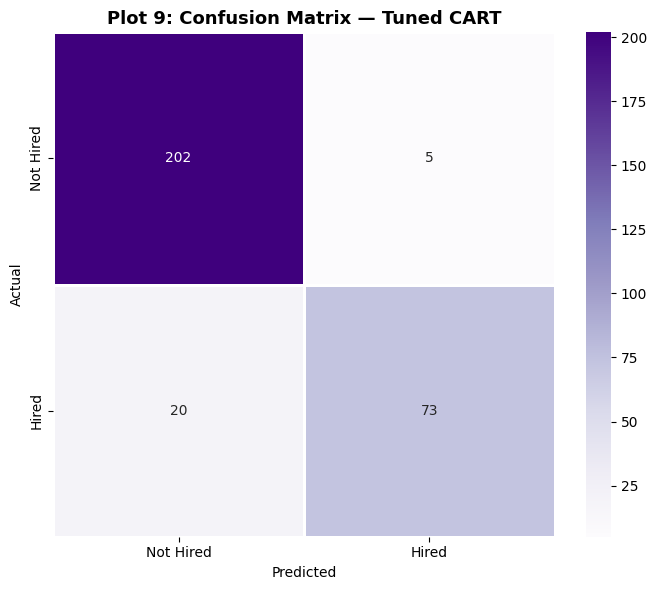

In [30]:
print("\n📋 Classification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned, target_names=['Not Hired', 'Hired']))

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['Not Hired', 'Hired'],
            yticklabels=['Not Hired', 'Hired'],
            linewidths=1, linecolor='white')
ax.set_title('Plot 9: Confusion Matrix — Tuned CART', fontsize=13, fontweight='bold')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

## PLOT 10: GridSearch Results — Top 20 Combinations

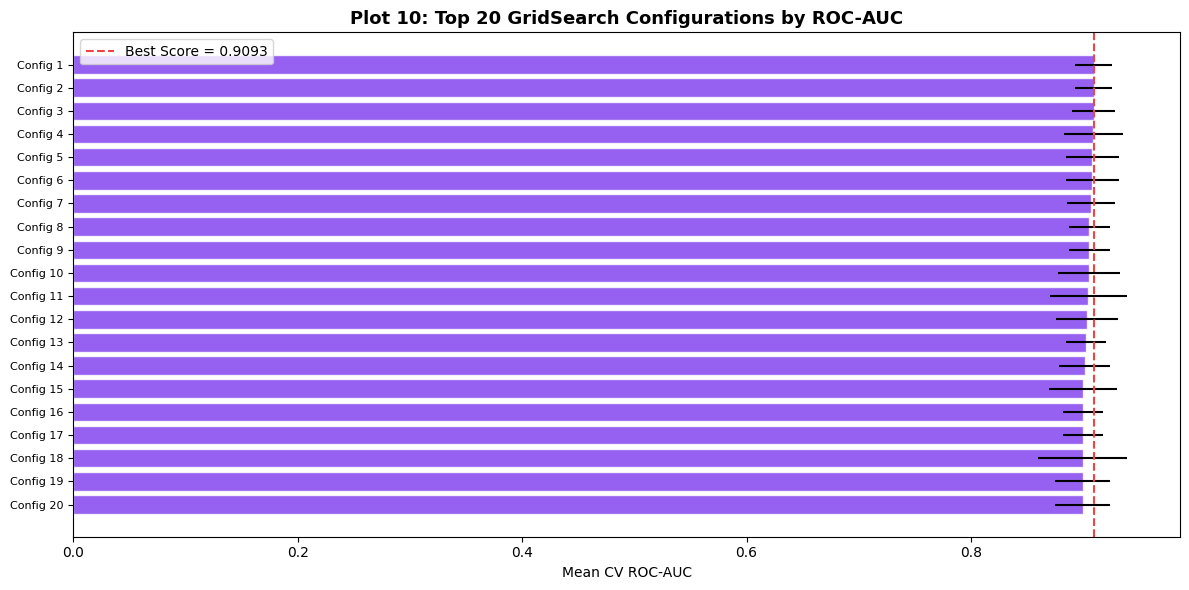

In [31]:
# Visualize how different parameter combinations performed
cv_results = pd.DataFrame(grid_search.cv_results_)   # All 90 results as a DataFrame
top20 = cv_results.nlargest(20, 'mean_test_score')    # Pick the top 20 by ROC-AUC
top20 = top20.reset_index(drop=True)                  # Reset index for clean plotting

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(20),                                    # Draw horizontal bars
        top20['mean_test_score'],                     # X-axis = ROC-AUC score
        xerr=top20['std_test_score'],                 # Error bars = std deviation
        color='#7C3AED', alpha=0.8, edgecolor='white')
ax.set_yticks(range(20))
ax.set_yticklabels([f"Config {i+1}" for i in range(20)], fontsize=8)
ax.invert_yaxis()                                     # Best config at top
ax.set_title('Plot 10: Top 20 GridSearch Configurations by ROC-AUC',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Mean CV ROC-AUC')
ax.axvline(grid_search.best_score_, color='#EF4444', linestyle='--',
           label=f'Best Score = {grid_search.best_score_:.4f}')
ax.legend()
plt.tight_layout()
plt.show()

## SECTION 11 : CROSS-VALIDATION (10-FOLD) — How Consistent Is Our Model?

In [32]:
# Cross-validation is like taking the same exam 10 times with different question papers.
# Each time, 90% of data is used for training and 10% for testing.
# If the model scores consistently across all 10 rounds → it generalizes well!
# High variance between rounds = the model is unstable.

In [33]:
# Run 10-fold cross-validation on the ENTIRE scaled dataset
# (not just the train set — CV handles the splitting internally)

In [34]:
cv_scores = cross_val_score(
    cart_tuned,                                       # The model to evaluate
    X_scaled,                                         # Full scaled feature data
    y,                                                # Full target vector
    cv=10,                                            # 10 folds
    scoring='roc_auc'                                 # Evaluate using ROC-AUC
)

print(f"\n  10-Fold CV ROC-AUC Scores:")
for i, score in enumerate(cv_scores):
    print(f"  Fold {i+1:>2}: {score:.4f}")

print(f"\n  Mean ROC-AUC : {cv_scores.mean():.4f}")
print(f"  Std Deviation: {cv_scores.std():.4f}  ← lower std = more consistent model")
print(f"  Min Score    : {cv_scores.min():.4f}")
print(f"  Max Score    : {cv_scores.max():.4f}")


  10-Fold CV ROC-AUC Scores:
  Fold  1: 0.9363
  Fold  2: 0.9900
  Fold  3: 0.9572
  Fold  4: 0.9814
  Fold  5: 0.9572
  Fold  6: 0.9724
  Fold  7: 0.9559
  Fold  8: 0.9845
  Fold  9: 0.8254
  Fold 10: 0.5826

  Mean ROC-AUC : 0.9143
  Std Deviation: 0.1193  ← lower std = more consistent model
  Min Score    : 0.5826
  Max Score    : 0.9900


#PLOT 11: Cross-Validation Scores Per Fold

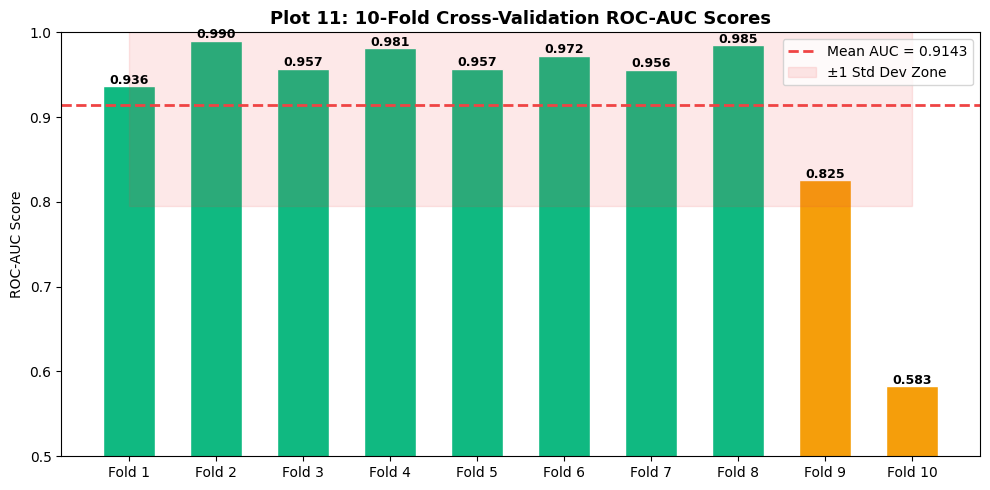

In [36]:
fig, ax = plt.subplots(figsize=(10, 5))
fold_labels = [f'Fold {i+1}' for i in range(10)]     # Labels for x-axis
bar_colors = ['#10B981' if s >= cv_scores.mean()
              else '#F59E0B' for s in cv_scores]      # Green = above average, Orange = below

ax.bar(fold_labels, cv_scores, color=bar_colors,
       edgecolor='white', width=0.6)                  # Draw one bar per fold
ax.axhline(cv_scores.mean(), color='#EF4444', linestyle='--', lw=2,
           label=f'Mean AUC = {cv_scores.mean():.4f}')  # Mean line
ax.fill_between(range(10),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.12, color='#EF4444',
                label='±1 Std Dev Zone')              # Shaded band = ± 1 std deviation

# Add value labels on each bar
for i, (rect, score) in enumerate(zip(ax.patches, cv_scores)):
    ax.text(rect.get_x() + rect.get_width() / 2,
            rect.get_height() + 0.003,
            f'{score:.3f}', ha='center', fontsize=9, fontweight='bold')

ax.set_title('Plot 11: 10-Fold Cross-Validation ROC-AUC Scores',
             fontsize=13, fontweight='bold')
ax.set_ylabel('ROC-AUC Score')
ax.set_ylim(0.5, 1.0)
ax.legend()
plt.tight_layout()
plt.show()                                             # 📺 Show inline!

print("=" * 70)



## SECTION 12 : OVERFITTING ANALYSIS — Is Our Model Too Smart For Its Own Good?
# Overfitting happens when a model memorizes the training data instead of learning patterns.
# Like a student who memorizes all past exam answers but fails when new questions appear.
# We test different tree depths and see where Train accuracy >> Test accuracy.
# That gap = overfitting zone.
# The optimal depth = where Test accuracy is highest before it starts dropping.

In [37]:
print("\nSECTION 12 : OVERFITTING ANALYSIS")
print("=" * 70)

depths = range(1, 21)                                 # Test tree depths from 1 to 20
train_scores = []                                     # Store training accuracy per depth
test_scores  = []                                     # Store test accuracy per depth

for d in depths:                                      # Loop through each depth value
    clf = DecisionTreeClassifier(
        max_depth=d,                                  # Set the depth we're testing
        random_state=42,
        criterion=grid_search.best_params_['criterion']  # Use the best criterion found earlier
    )
    clf.fit(X_train, y_train)                         # Train on training set
    train_scores.append(accuracy_score(y_train, clf.predict(X_train)))  # Score on training
    test_scores.append(accuracy_score(y_test, clf.predict(X_test)))     # Score on test

# Find the depth that gives the best test accuracy
best_depth_idx = np.argmax(test_scores)               # Index of maximum test score
best_depth = list(depths)[best_depth_idx]             # The actual best depth

print(f"  Optimal Tree Depth (best test accuracy) : {best_depth}")
print(f"  Train Accuracy at depth {best_depth}: {train_scores[best_depth_idx]:.4f}")
print(f"  Test  Accuracy at depth {best_depth}: {test_scores[best_depth_idx]:.4f}")
print(f"\n  Interpretation:")
print(f"  - Depths 1-{best_depth}: Underfitting (model too simple, misses patterns)")
print(f"  - Depth {best_depth}: Goldilocks zone (just right!)")
print(f"  - Depths > {best_depth}: Overfitting (model memorizes noise)")


SECTION 12 : OVERFITTING ANALYSIS
  Optimal Tree Depth (best test accuracy) : 6
  Train Accuracy at depth 6: 0.9675
  Test  Accuracy at depth 6: 0.9333

  Interpretation:
  - Depths 1-6: Underfitting (model too simple, misses patterns)
  - Depth 6: Goldilocks zone (just right!)
  - Depths > 6: Overfitting (model memorizes noise)


#PLOT 12: Overfitting Analysis Graph

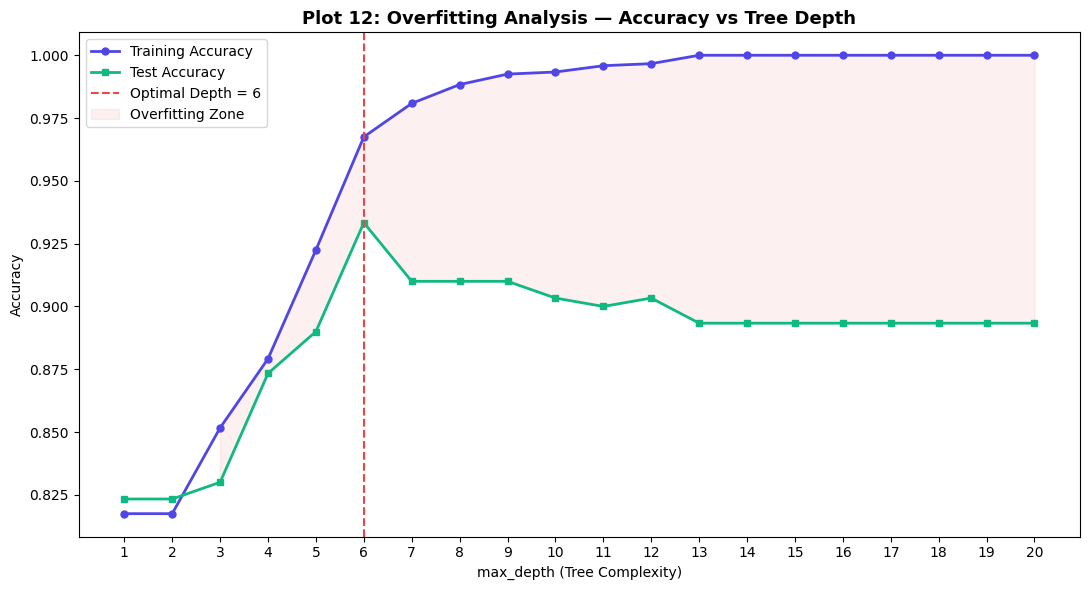

In [38]:
fig, ax = plt.subplots(figsize=(11, 6))
ax.plot(depths, train_scores, 'o-', color='#4F46E5', lw=2,
        label='Training Accuracy', markersize=5)     # Blue line = training accuracy
ax.plot(depths, test_scores,  's-', color='#10B981', lw=2,
        label='Test Accuracy',     markersize=5)     # Green line = test accuracy
ax.axvline(best_depth, color='#EF4444', linestyle='--', lw=1.5,
           label=f'Optimal Depth = {best_depth}')    # Red line = optimal depth

# Shade the overfitting zone (where train > test)
ax.fill_between(depths,
                train_scores, test_scores,
                where=[t > v for t, v in zip(train_scores, test_scores)],
                alpha=0.08, color='#EF4444', label='Overfitting Zone')

ax.set_title('Plot 12: Overfitting Analysis — Accuracy vs Tree Depth',
             fontsize=13, fontweight='bold')
ax.set_xlabel('max_depth (Tree Complexity)')
ax.set_ylabel('Accuracy')
ax.legend()
ax.set_xticks(list(depths))
plt.tight_layout()
plt.show()

#SECTION 13 : COST COMPLEXITY PRUNING (CCP) — Trimming the Tree
# Pruning is like trimming a tree in your garden.
# We cut branches that don't contribute much to improve generalization.
# CCP Alpha is the "pruning strength" parameter.
# Low alpha = keep most branches (complex tree)
# High alpha = cut aggressively (simple tree)
# We test many alpha values and pick the one with best test accuracy.

  Number of alpha values to test: 48

  Best CCP Alpha         : 0.001944
  Train Accuracy (pruned): 0.9592
  Test  Accuracy (pruned): 0.9400


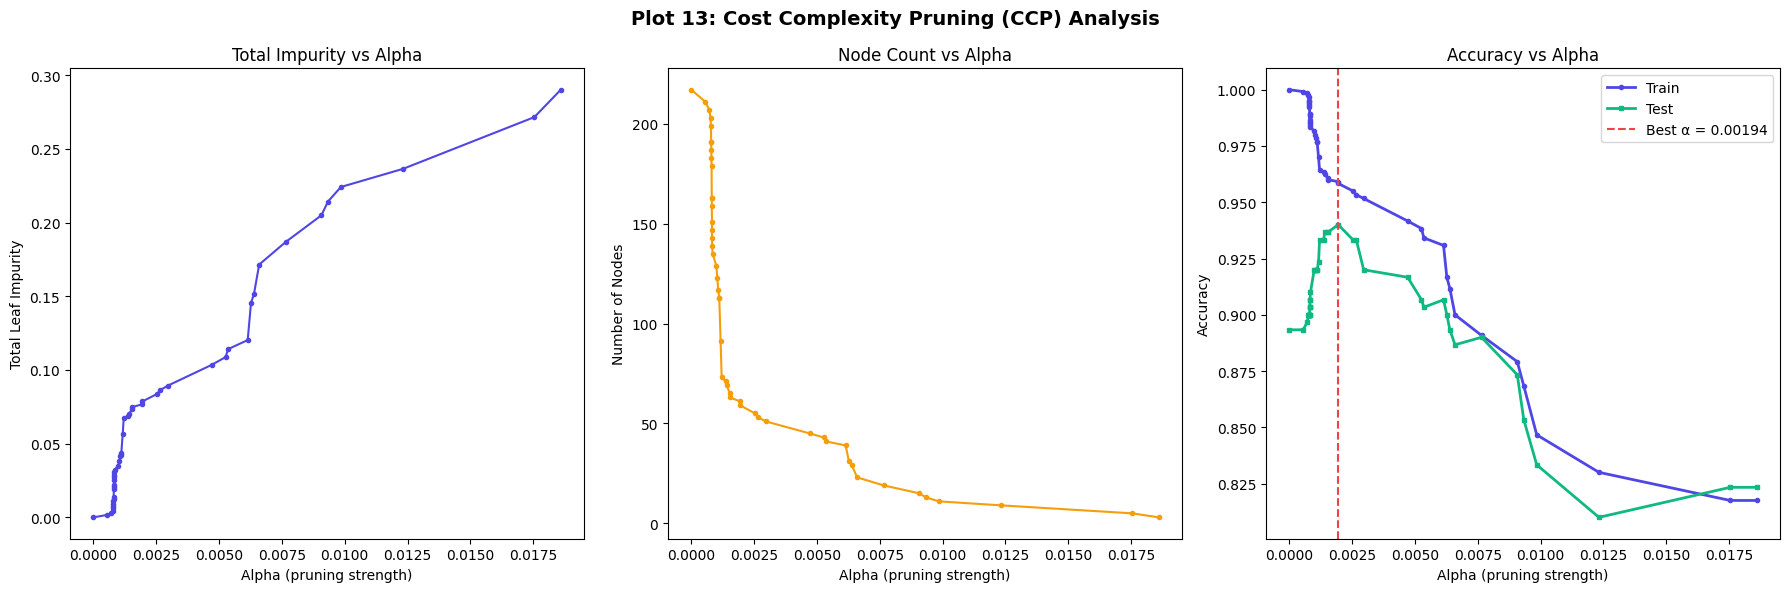


  Pruned Tree Depth  : 6
  Pruned Leaves      : 31
  Pruned Accuracy    : 0.9400
  Pruned ROC-AUC     : 0.9256


In [39]:
# Get the sequence of effective alphas — the values at which branches get pruned
path = DecisionTreeClassifier(random_state=42).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[:-1]                    # Exclude the last (trivial) alpha
impurities  = path.impurities[:-1]                   # Total leaf impurity at each alpha

print(f"  Number of alpha values to test: {len(ccp_alphas)}")

# Train one tree per alpha value and record performance
ccp_train_scores = []                                 # Training accuracy at each alpha
ccp_test_scores  = []                                 # Test accuracy at each alpha
ccp_n_nodes      = []                                 # Number of tree nodes at each alpha

for alpha in ccp_alphas:                             # Try each alpha value
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X_train, y_train)
    ccp_train_scores.append(accuracy_score(y_train, clf.predict(X_train)))
    ccp_test_scores.append(accuracy_score(y_test, clf.predict(X_test)))
    ccp_n_nodes.append(clf.tree_.node_count)         # Total number of decision nodes

# Find the best alpha (highest test accuracy)
best_alpha_idx = np.argmax(ccp_test_scores)           # Index of best test score
best_alpha     = ccp_alphas[best_alpha_idx]           # The best alpha value

print(f"\n  Best CCP Alpha         : {best_alpha:.6f}")
print(f"  Train Accuracy (pruned): {ccp_train_scores[best_alpha_idx]:.4f}")
print(f"  Test  Accuracy (pruned): {ccp_test_scores[best_alpha_idx]:.4f}")


# ── PLOT 13: CCP Analysis — 3 Subplots ────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Plot 13: Cost Complexity Pruning (CCP) Analysis',
             fontsize=14, fontweight='bold')

# Subplot A: Impurity vs Alpha — how messy the leaves get as we prune
axes[0].plot(ccp_alphas, impurities, 'o-', color='#4F46E5', markersize=3)
axes[0].set_title('Total Impurity vs Alpha')
axes[0].set_xlabel('Alpha (pruning strength)')
axes[0].set_ylabel('Total Leaf Impurity')

# Subplot B: Node count vs Alpha — how the tree shrinks as we prune
axes[1].plot(ccp_alphas, ccp_n_nodes, 'o-', color='#F59E0B', markersize=3)
axes[1].set_title('Node Count vs Alpha')
axes[1].set_xlabel('Alpha (pruning strength)')
axes[1].set_ylabel('Number of Nodes')

# Subplot C: Accuracy vs Alpha — where train and test accuracy diverge
axes[2].plot(ccp_alphas, ccp_train_scores, 'o-', color='#4F46E5', lw=2,
             label='Train', markersize=3)
axes[2].plot(ccp_alphas, ccp_test_scores, 's-', color='#10B981', lw=2,
             label='Test', markersize=3)
axes[2].axvline(best_alpha, color='#EF4444', linestyle='--',
                label=f'Best α = {best_alpha:.5f}')
axes[2].set_title('Accuracy vs Alpha')
axes[2].set_xlabel('Alpha (pruning strength)')
axes[2].set_ylabel('Accuracy')
axes[2].legend()

plt.tight_layout()
plt.show()                                             # 📺 Show inline!

# Build the final pruned model using the best alpha
cart_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
cart_pruned.fit(X_train, y_train)                     # Train the pruned model

y_pred_pruned = cart_pruned.predict(X_test)           # Predictions from pruned model
y_prob_pruned = cart_pruned.predict_proba(X_test)[:, 1]  # Probabilities from pruned model

print(f"\n  Pruned Tree Depth  : {cart_pruned.get_depth()}")
print(f"  Pruned Leaves      : {cart_pruned.get_n_leaves()}")
print(f"  Pruned Accuracy    : {accuracy_score(y_test, y_pred_pruned):.4f}")
print(f"  Pruned ROC-AUC     : {roc_auc_score(y_test, y_prob_pruned):.4f}")

## SECTION 14 : MODEL COMPARISON — Who Wins?
# Now we compare all 3 models side by side:
# - Baseline CART (no tuning, default settings)
# - Tuned CART    (GridSearchCV found the best hyperparameters)
# - Pruned CART   (CCP alpha removed unnecessary branches)

# Winner = the model that best balances accuracy, AUC, and simplicity.

In [42]:
# Helper function to calculate all metrics for a model
def get_metrics(name, y_true, y_pred, y_prob, model):
    return {
        'Model'        : name,
        'Accuracy'     : round(accuracy_score(y_true, y_pred), 4),       # % correct predictions
        'ROC-AUC'      : round(roc_auc_score(y_true, y_prob), 4),        # Discrimination ability
        'Avg Precision': round(average_precision_score(y_true, y_prob), 4), # PR-AUC score
        'Tree Depth'   : model.get_depth(),                               # How deep the tree is
        'Num Leaves'   : model.get_n_leaves(),                            # Total leaf nodes
    }

# Build comparison DataFrame
comparison_df = pd.DataFrame([
    get_metrics('Baseline CART', y_test, y_pred_base,   y_prob_base,   cart_base),
    get_metrics('Tuned CART',    y_test, y_pred_tuned,  y_prob_tuned,  cart_tuned),
    get_metrics('Pruned CART',   y_test, y_pred_pruned, y_prob_pruned, cart_pruned),
]).set_index('Model')

print("\n Model Comparison Table:")
print(comparison_df.to_string())


 Model Comparison Table:
               Accuracy  ROC-AUC  Avg Precision  Tree Depth  Num Leaves
Model                                                                  
Baseline CART    0.8933   0.8724         0.7392          13         109
Tuned CART       0.9167   0.9116         0.8506          12          77
Pruned CART      0.9400   0.9256         0.8869           6          31


#PLOT 14: ROC Curves for All 3 Models

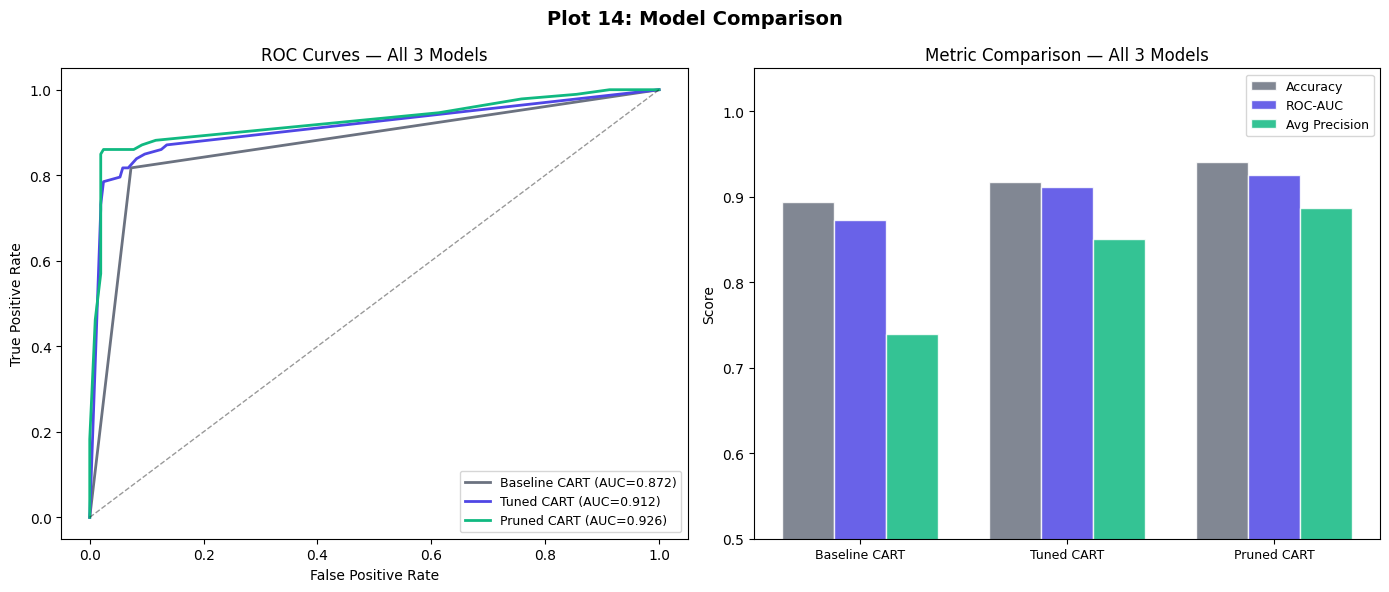


  🏆 Best Model (by ROC-AUC): Pruned CART
     ROC-AUC  : 0.9256
     Accuracy : 0.9400


In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Plot 14: Model Comparison', fontsize=14, fontweight='bold')

# Left: ROC Curves overlaid
for name, y_prob, color in [
    ('Baseline CART', y_prob_base,   '#6B7280'),
    ('Tuned CART',    y_prob_tuned,  '#4F46E5'),
    ('Pruned CART',   y_prob_pruned, '#10B981'),
]:
    fpr_, tpr_, _ = roc_curve(y_test, y_prob)         # Compute ROC coordinates
    auc_ = roc_auc_score(y_test, y_prob)              # Compute AUC
    axes[0].plot(fpr_, tpr_, lw=2, color=color,
                 label=f'{name} (AUC={auc_:.3f})')   # Plot ROC curve

axes[0].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.4) # Diagonal = random baseline
axes[0].set_title('ROC Curves — All 3 Models')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend(fontsize=9)

# Right: Bar chart comparing metrics
metrics_bar = comparison_df[['Accuracy', 'ROC-AUC', 'Avg Precision']] # Select 3 metrics
x = np.arange(len(metrics_bar.index))                 # X positions for each model
w = 0.25                                              # Width of each bar
bar_colors = ['#6B7280', '#4F46E5', '#10B981']        # One color per metric

for i, (col, c) in enumerate(zip(metrics_bar.columns, bar_colors)):
    axes[1].bar(x + i * w, metrics_bar[col], width=w, label=col,
                color=c, edgecolor='white', alpha=0.85)

axes[1].set_xticks(x + w)
axes[1].set_xticklabels(metrics_bar.index, fontsize=9)
axes[1].set_ylim(0.5, 1.05)
axes[1].set_title('Metric Comparison — All 3 Models')
axes[1].set_ylabel('Score')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()                                             # 📺 Show inline!

# Print winner
best_model = comparison_df['ROC-AUC'].idxmax()        # Model with highest ROC-AUC
print(f"\n  🏆 Best Model (by ROC-AUC): {best_model}")
print(f"     ROC-AUC  : {comparison_df.loc[best_model, 'ROC-AUC']:.4f}")
print(f"     Accuracy : {comparison_df.loc[best_model, 'Accuracy']:.4f}")


## SECTION 15 : FEATURE IMPORTANCE — Tuned Model Edition
# Same as Section 9, but now we look at which features matter most
# in the TUNED model (which may differ from the baseline!).

In [44]:
print("\nSECTION 15 : FEATURE IMPORTANCE (Tuned Model)")
print("=" * 70)

feat_imp_tuned = pd.Series(
    cart_tuned.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\n  Feature Importance Scores (Tuned CART):")
for feat, score in feat_imp_tuned.items():
    bar = "█" * int(score * 50)
    print(f"  {feat:<25} {score:.4f}  {bar}")



SECTION 15 : FEATURE IMPORTANCE (Tuned Model)

  Feature Importance Scores (Tuned CART):
  RecruitmentStrategy       0.3705  ██████████████████
  ExperienceYears           0.1390  ██████
  SkillScore                0.1344  ██████
  InterviewScore            0.1277  ██████
  PersonalityScore          0.1091  █████
  EducationLevel            0.0922  ████
  Age                       0.0127  
  DistanceFromCompany       0.0124  
  PreviousCompanies         0.0019  
  Gender                    0.0000  


#PLOT 15: Feature Importance — Tuned Model

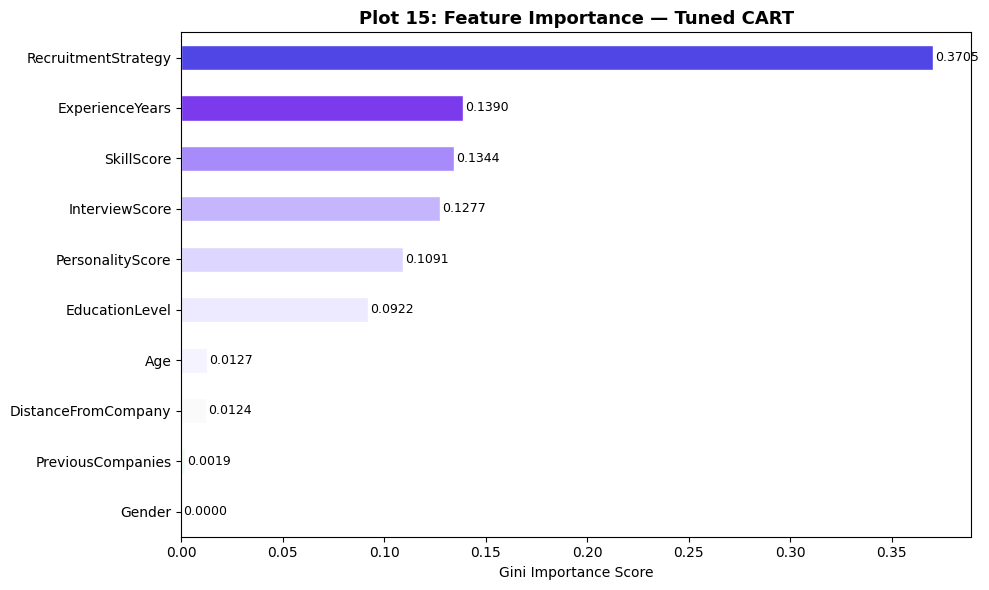


  Top 3 Most Influential Features:
  → RecruitmentStrategy
  → ExperienceYears
  → SkillScore


In [45]:
fig, ax = plt.subplots(figsize=(10, 6))
palette_feat = ['#4F46E5', '#7C3AED', '#A78BFA', '#C4B5FD',
                '#DDD6FE', '#EDE9FE', '#F5F3FF', '#FAFAFA',
                '#F0FDF4', '#D1FAE5']                 # Different shades for each feature
feat_imp_tuned.plot(kind='barh', ax=ax,
                    color=palette_feat[:len(feat_imp_tuned)],
                    edgecolor='white')
ax.invert_yaxis()
ax.set_title('Plot 15: Feature Importance — Tuned CART', fontsize=13, fontweight='bold')
ax.set_xlabel('Gini Importance Score')
for i, v in enumerate(feat_imp_tuned.values):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()                                             # 📺 Show inline!

print(f"\n  Top 3 Most Influential Features:")
for feat in feat_imp_tuned.head(3).index:
    print(f"  → {feat}")


## SECTION 16 : PREDICTION FUNCTION — Ask the Model About Any Candidate

# Now we create a reusable function that takes a candidate's details
# and returns a hiring prediction + probability + confidence level.

In [48]:
def predict_hiring(age, gender, education_level, experience_years,
                   previous_companies, distance_from_company,
                   interview_score, skill_score, personality_score,
                   recruitment_strategy,
                   model=cart_tuned,                  # Use tuned model by default
                   scaler_obj=scaler):                # Use the same scaler used during training
    """
    Predicts the hiring decision for a single candidate.

    Parameters
    ----------
    age                   : int   — Candidate age (e.g., 28)
    gender                : int   — 0 = Female, 1 = Male
    education_level       : int   — 1=High School, 2=Bachelor, 3=Master, 4=PhD
    experience_years      : int   — Years of work experience
    previous_companies    : int   — Number of previous employers
    distance_from_company : float — Distance from office in km
    interview_score       : int   — Interview performance score (0–100)
    skill_score           : int   — Technical skill score (0–100)
    personality_score     : int   — Personality assessment score (0–100)
    recruitment_strategy  : int   — 1=Aggressive, 2=Moderate, 3=Conservative

    Returns
    -------
    dict — contains Decision (HIRED/NOT HIRED), Probability, and Confidence level
    """

    # Pack the inputs into a 2D array (shape: 1 row, 10 features)
    features = np.array([[age, gender, education_level, experience_years,
                          previous_companies, distance_from_company,
                          interview_score, skill_score, personality_score,
                          recruitment_strategy]])

    # Scale the input using the SAME scaler from training
    # (Critical: don't create a new scaler — the model learned on these exact scales)
    features_scaled = scaler_obj.transform(features)   # Apply trained scaler

    # Make the prediction
    pred = model.predict(features_scaled)[0]           # Binary: 0 or 1
    prob = model.predict_proba(features_scaled)[0][1]  # Probability of being Hired

    # Assign a confidence label based on probability
    if prob >= 0.75:
        confidence = 'HIGH 🟢'
    elif prob >= 0.50:
        confidence = 'MODERATE 🟡'
    else:
        confidence = 'LOW 🔴'

    return {
        'Decision'   : 'HIRED ' if pred == 1 else 'NOT HIRED ',
        'Probability': f'{prob:.2%}',
        'Confidence' : confidence,
    }

In [49]:
# ── Demo Prediction 1 ─────────────────────────────────────────────────────────
print("\n👤 Candidate 1: Fresh Master's grad, 4 years experience, decent scores")
result1 = predict_hiring(
    age=28, gender=1, education_level=3, experience_years=4,
    previous_companies=2, distance_from_company=10.5,
    interview_score=75, skill_score=80, personality_score=70,
    recruitment_strategy=2
)
for k, v in result1.items():
    print(f"  {k:<15} : {v}")

# ── Demo Prediction 2 ─────────────────────────────────────────────────────────
print("\n👤 Candidate 2: PhD, 10 years experience, very high scores")
result2 = predict_hiring(
    age=35, gender=0, education_level=4, experience_years=10,
    previous_companies=3, distance_from_company=5.0,
    interview_score=90, skill_score=92, personality_score=85,
    recruitment_strategy=1
)
for k, v in result2.items():
    print(f"  {k:<15} : {v}")

# ── Demo Prediction 3 ─────────────────────────────────────────────────────────
print("\n👤 Candidate 3: High school only, no experience, low scores")
result3 = predict_hiring(
    age=22, gender=1, education_level=1, experience_years=0,
    previous_companies=0, distance_from_company=45.0,
    interview_score=30, skill_score=25, personality_score=40,
    recruitment_strategy=3
)
for k, v in result3.items():
    print(f"  {k:<15} : {v}")


👤 Candidate 1: Fresh Master's grad, 4 years experience, decent scores
  Decision        : HIRED 
  Probability     : 100.00%
  Confidence      : HIGH 🟢

👤 Candidate 2: PhD, 10 years experience, very high scores
  Decision        : HIRED 
  Probability     : 100.00%
  Confidence      : HIGH 🟢

👤 Candidate 3: High school only, no experience, low scores
  Decision        : NOT HIRED 
  Probability     : 0.00%
  Confidence      : LOW 🔴


## SECTION 17 : FINAL SUMMARY & BUSINESS INSIGHTS

In [50]:
best_model_name = comparison_df['ROC-AUC'].idxmax()   # Model with best ROC-AUC
best_auc        = comparison_df['ROC-AUC'].max()
best_acc        = comparison_df.loc[best_model_name, 'Accuracy']

print(f"""
╔══════════════════════════════════════════════════════════════════════╗
║                    PROJECT SUMMARY : CART ML MODEL                  ║
╚══════════════════════════════════════════════════════════════════════╝

📊 Final Model Comparison:
{comparison_df.to_string()}

🏆 Best Model     : {best_model_name}
   ROC-AUC        : {best_auc:.4f}
   Accuracy       : {best_acc:.4f}

🔍 Top 3 Key Predictors:
   1. {feat_imp_tuned.index[0]} — Most important hiring signal
   2. {feat_imp_tuned.index[1]} — Second most important
   3. {feat_imp_tuned.index[2]} — Third most important

📌 KEY FINDINGS:
──────────────────────────────────────────────────────────────────────
1. OVERFITTING: The baseline (no limits) tree was VERY deep and
   memorized training data. GridSearchCV solved this by limiting depth
   and requiring minimum samples at each split.

2. TUNING IMPACT: GridSearchCV tested 90 parameter combinations with
   5-fold cross-validation (450 total model fits!) and found the best
   hyperparameters automatically.

3. PRUNING: CCP removed branches that added complexity without
   improving generalization → simpler, more interpretable tree
   with competitive accuracy.

4. CLASS IMBALANCE: Only 31% of candidates were Hired. This is why
   ROC-AUC is more reliable than accuracy for this problem.
   (A dumb model that predicts "Not Hired" always would get 69% accuracy!)

BUSINESS RECOMMENDATIONS FOR HR TEAMS:
──────────────────────────────────────────────────────────────────────
• InterviewScore + SkillScore are the strongest predictors → invest
  in structured, standardized assessments for ALL candidates.

• ExperienceYears matters, but CART captures its non-linear effect
  (experience beyond a threshold doesn't always help more).

• CART is ideal for HR stakeholders who need EXPLAINABILITY —
  the tree diagram can be shown to non-technical managers.

  LIMITATIONS OF CART:
──────────────────────────────────────────────────────────────────────
• Single trees have HIGH VARIANCE — small data changes can completely
  change the tree structure. (Solution: use Random Forest / XGBoost)

• CART cannot capture complex feature interactions beyond splits.

• For production systems, consider ensemble models + SHAP for
  explanation rather than a single decision tree.


""")

print("=" * 70)
print("  🎉 END OF CART ML PROJECT")
print("=" * 70)







╔══════════════════════════════════════════════════════════════════════╗
║                    PROJECT SUMMARY : CART ML MODEL                  ║
╚══════════════════════════════════════════════════════════════════════╝
 
📊 Final Model Comparison:
               Accuracy  ROC-AUC  Avg Precision  Tree Depth  Num Leaves
Model                                                                  
Baseline CART    0.8933   0.8724         0.7392          13         109
Tuned CART       0.9167   0.9116         0.8506          12          77
Pruned CART      0.9400   0.9256         0.8869           6          31
 
🏆 Best Model     : Pruned CART
   ROC-AUC        : 0.9256
   Accuracy       : 0.9400
 
🔍 Top 3 Key Predictors:
   1. RecruitmentStrategy — Most important hiring signal
   2. ExperienceYears — Second most important
   3. SkillScore — Third most important
 
📌 KEY FINDINGS:
──────────────────────────────────────────────────────────────────────
1. OVERFITTING: The baseline (no limits) tree wa